# file in cui faccio cose per capire cose


capendo come funzionano gli alberi: se ho che   
$ x = 2 \rightarrow y = 1 $  
$ x = 3 \rightarrow y = -1 $  
$ x = 4 \rightarrow y = 1 $   
$ x = 5 \rightarrow y = -1 $  
come fa gli split l'albero?


In [ ]:
import numpy as np 

x_sample = [2,3,4,5,6,7]

def f_star(x):

    return (-1) ** x



step 1: [2, 3, 4, 5, 6, 7] -> x <= 4.5: [2, 3, 4] | x > 4.5: [5, 6, 7]
    step 2: [2, 3, 4] -> x <= 2.5: [2] | x > 2.5: [3, 4]
        step 3: [3, 4] -> x <= 3.5: [3] | x > 3.5: [4]


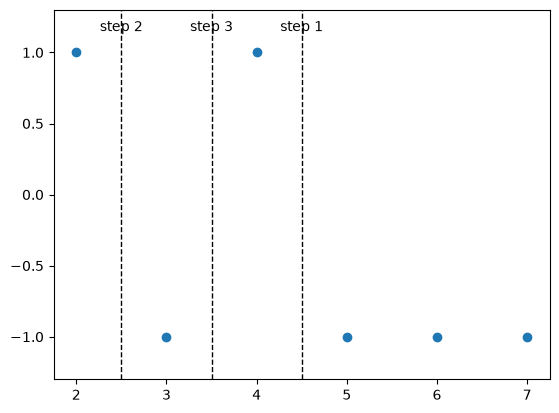

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

x = np.array(x_sample)
y = [1,-1,1,-1,-1,-1]
clf = DecisionTreeClassifier(max_depth=3).fit(x.reshape(-1, 1), y)
t = clf.tree_

# visita l'albero: per ogni nodo, quali punti contiene e dove li divide
def show_split(node, pts, step=1):
    if t.children_left[node] == -1:
        return
    thr = t.threshold[node]
    left, right = pts[pts <= thr], pts[pts > thr]
    print("    " * (step - 1) + f"step {step}: {pts.tolist()} -> x <= {thr}: {left.tolist()} | x > {thr}: {right.tolist()}")
    plt.axvline(thr, ls="--", color="k", lw=1)
    plt.text(thr, 1.15, f"step {step}", ha="center")
    show_split(t.children_left[node], left, step + 1)
    show_split(t.children_right[node], right, step + 1)

plt.scatter(x, y)
show_split(0, x)
plt.ylim(-1.3, 1.3)
plt.show()

This confirms my intuition on how trees work: the order of the $x$ s matters, because the algorithm splits the interval at some value of $x$ at each iteration.  

(vedi foto lavagna)